In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# importiung the dataset
df = pd.read_csv('../dataset/processed/creditcard.csv',encoding='latin-1')

# to show all the columns
pd.set_option( 'display.max_columns',None)

#create the copy of the dataset
df_copy = df.copy(deep=True)
df_copy.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0


In [47]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [48]:
# check if there is any null values or not
df_copy.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [49]:
# now checking for dupliaced values

# before removing the duplicate
print("Before",df_copy.shape)

df_copy.duplicated().sum()


Before (284807, 31)


np.int64(1081)

In [50]:
# after removing the duplicate

df_copy.drop_duplicates(inplace=True)

print("After",df_copy.shape)


After (283726, 31)


In [51]:
# remove the time columns
df_copy.drop(columns=['Time'], inplace=True)

In [52]:
df_copy.shape

(283726, 30)

In [53]:
# now Scale the amount

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_copy['Amount'] = scaler.fit_transform(df_copy['Amount'].values.reshape(-1,1))

# SPLIT THE FEATURES AND TARGET COLUMNS

In [54]:
df_copy.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
      dtype='object')

In [55]:
X = df_copy.drop(columns=['Class'])
y = df_copy['Class']

In [56]:
X.head(3)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900


In [57]:
y.head(3)

0    0
1    0
2    0
Name: Class, dtype: int64

In [58]:
y.value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

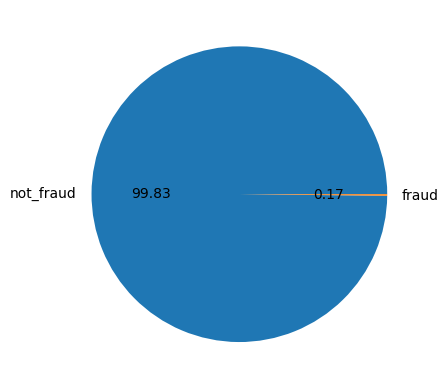

In [59]:
plt.pie(df_copy['Class'].value_counts(),labels=['not_fraud','fraud'],autopct='%.2f')
plt.show()

In [60]:
# train_test_split
from sklearn.model_selection import train_test_split


X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.35,random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,test_size=0.67,stratify=y_temp,random_state=42)

In [61]:
# now use weight to balance the inblance Class

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y)
print(classes)

[0 1]


In [66]:
# compute the class weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

In [63]:
class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5008349426131409), np.int64(1): np.float64(299.9217758985201)}


# BUILD ANN MODEL

In [65]:
import tensorflow as tf
from tensorflow.keras.models import Sequential # type:ignore
from tensorflow.keras.layers import Dense # type:ignore

model= Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\ASUS\OneDrive\Desktop\py\venvcls\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=256,
    validation_data=(X_val, y_val),
    class_weight=class_weights
)

Epoch 1/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9703 - loss: 0.2269 - val_accuracy: 0.9737 - val_loss: 0.1251
Epoch 2/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9704 - loss: 0.1480 - val_accuracy: 0.9600 - val_loss: 0.1423
Epoch 3/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9740 - loss: 0.1261 - val_accuracy: 0.9846 - val_loss: 0.0686
Epoch 4/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9789 - loss: 0.1060 - val_accuracy: 0.9837 - val_loss: 0.0629
Epoch 5/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9791 - loss: 0.0966 - val_accuracy: 0.9720 - val_loss: 0.0921
Epoch 6/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9816 - loss: 0.0767 - val_accuracy: 0.9857 - val_loss: 0.0477
Epoch 7/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9808 - loss: 0.0728 - val_accuracy: 0.9774 - val_loss: 0.0660
Epoch 8/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9795 - loss: 0.0663 - val_accuracy: 0.

In [68]:
model.evaluate(X_test, y_test)

2080/2080 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9883 - loss: 0.0436


[0.04363171383738518, 0.9883068799972534]

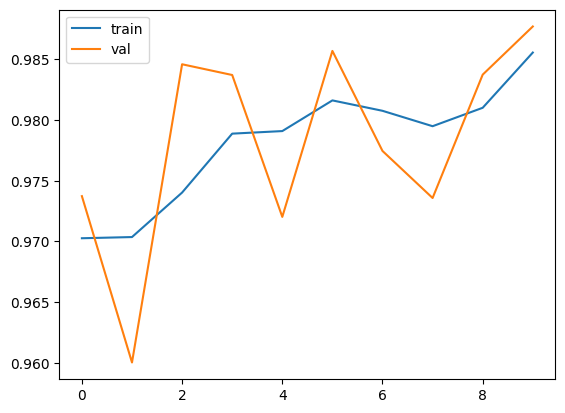

In [69]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.show()

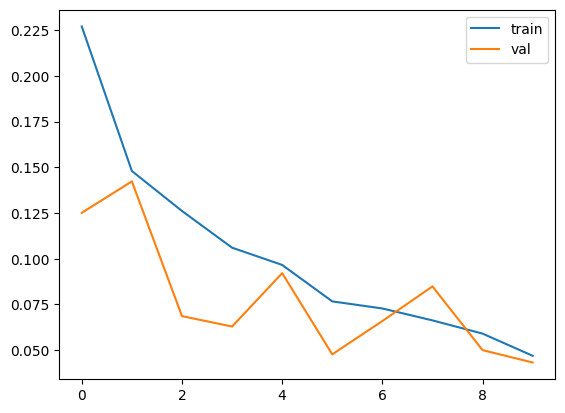

In [70]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.show()